**Dataset Description:**

Use the Glass dataset and apply the Random forest model.

**1. Exploratory Data Analysis (EDA):**

Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, inconsistencies in the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_excel('glass.xlsx', sheet_name=1)
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [5]:
df.shape

(214, 10)

In [6]:
df.size

2140

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [9]:
df.dtypes

,0
RI,float64
Na,float64
Mg,float64
Al,float64
Si,float64
K,float64
Ca,float64
Ba,float64
Fe,float64
Type,int64


In [10]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [11]:
df.isnull().sum()

,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


In [12]:
df.duplicated().sum()

np.int64(1)

In [ ]:
#drop the duplicates
df = df.drop_duplicates()

In [15]:
df.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [17]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


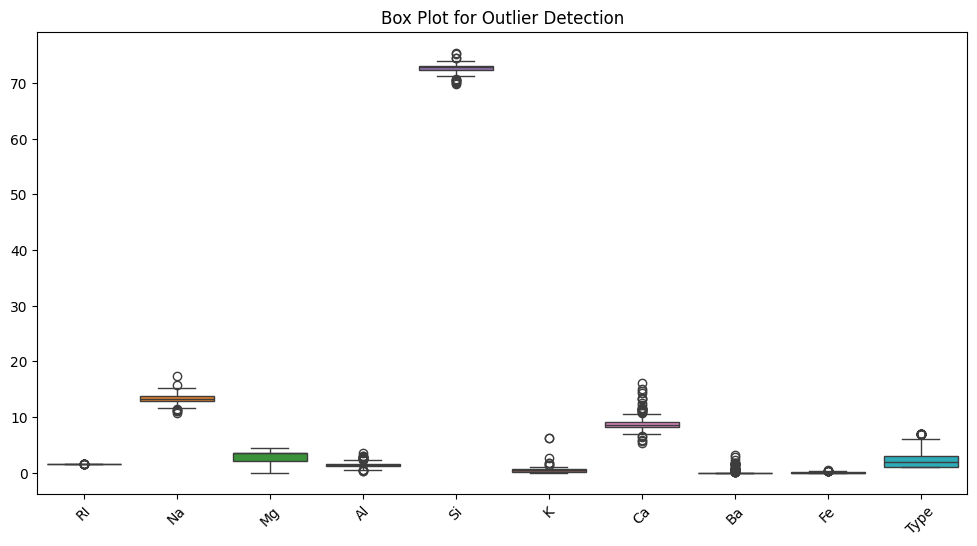

In [18]:
#checking outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Box Plot for Outlier Detection")
plt.show()

In [23]:
#capping outliers
for col in df.columns:
    if col != 'Type':
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])


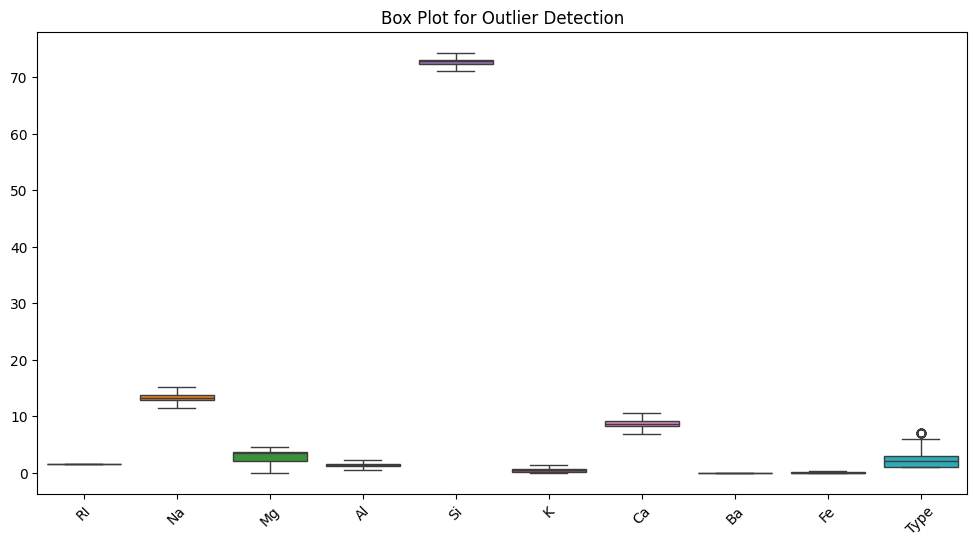

In [24]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Box Plot for Outlier Detection")
plt.show()

In [19]:
df.nunique()

,0
RI,178
Na,142
Mg,94
Al,118
Si,133
K,65
Ca,143
Ba,34
Fe,32
Type,6


**2: Data Visualization:**    
Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.

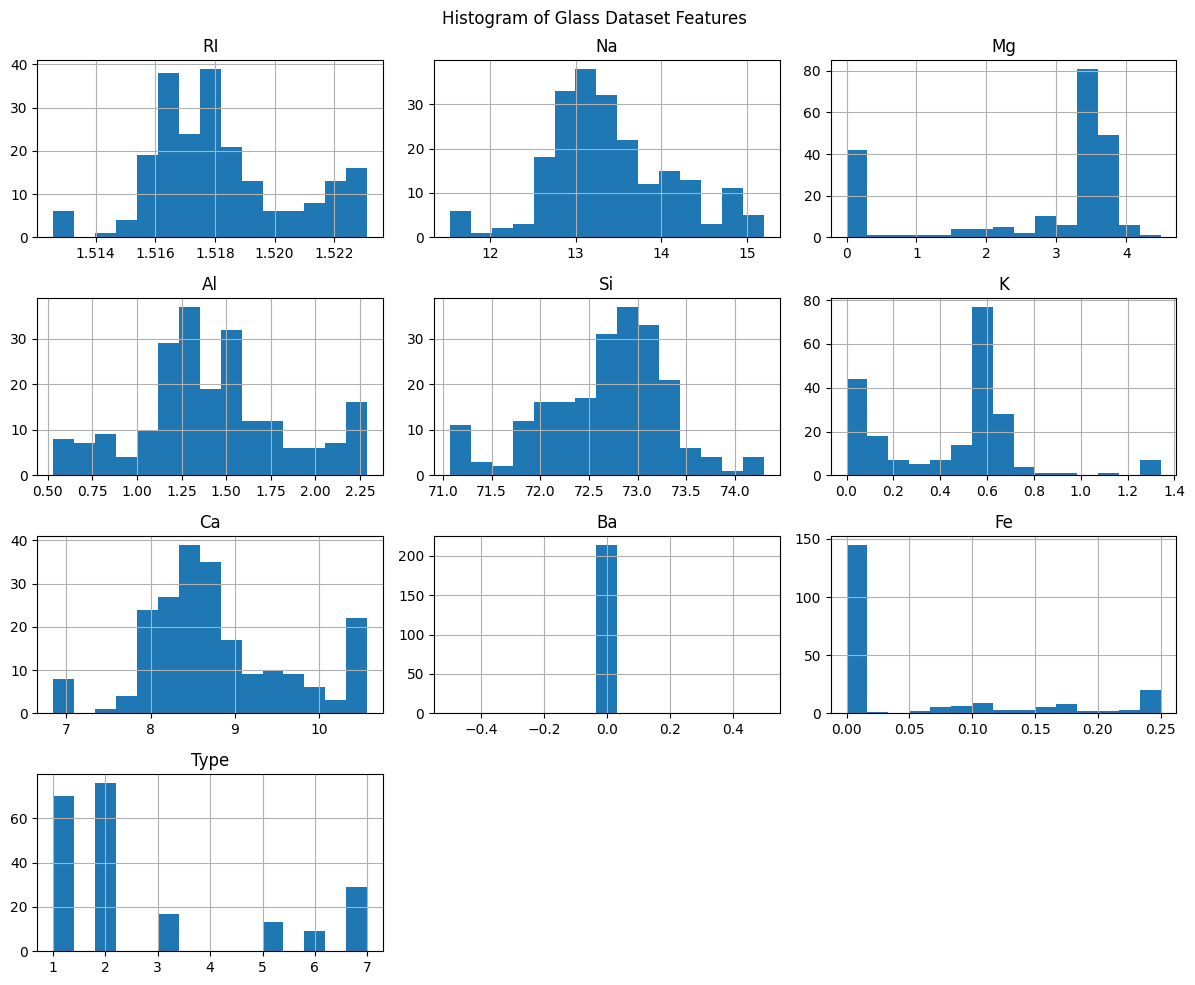

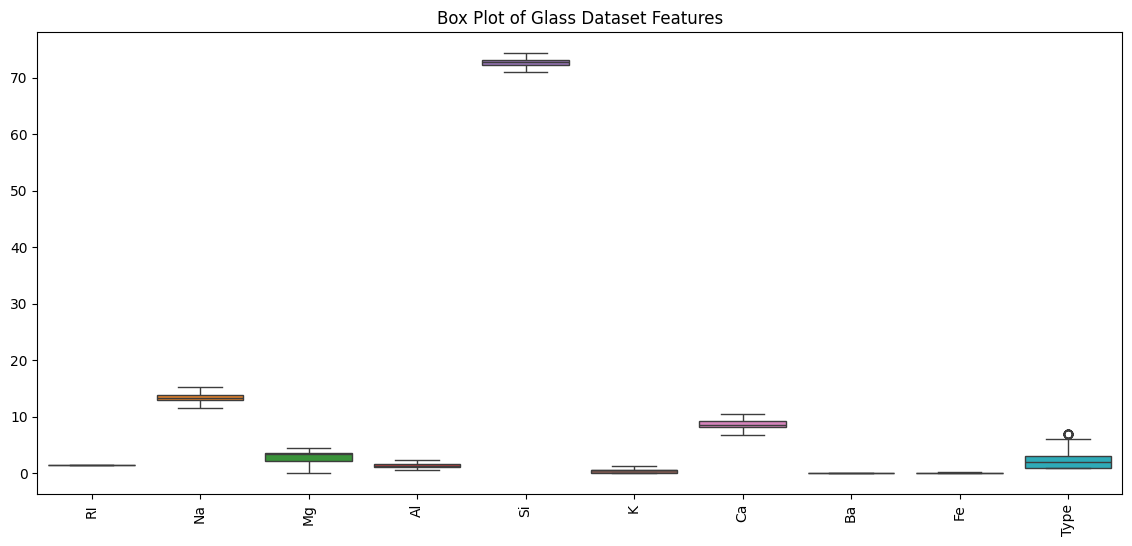

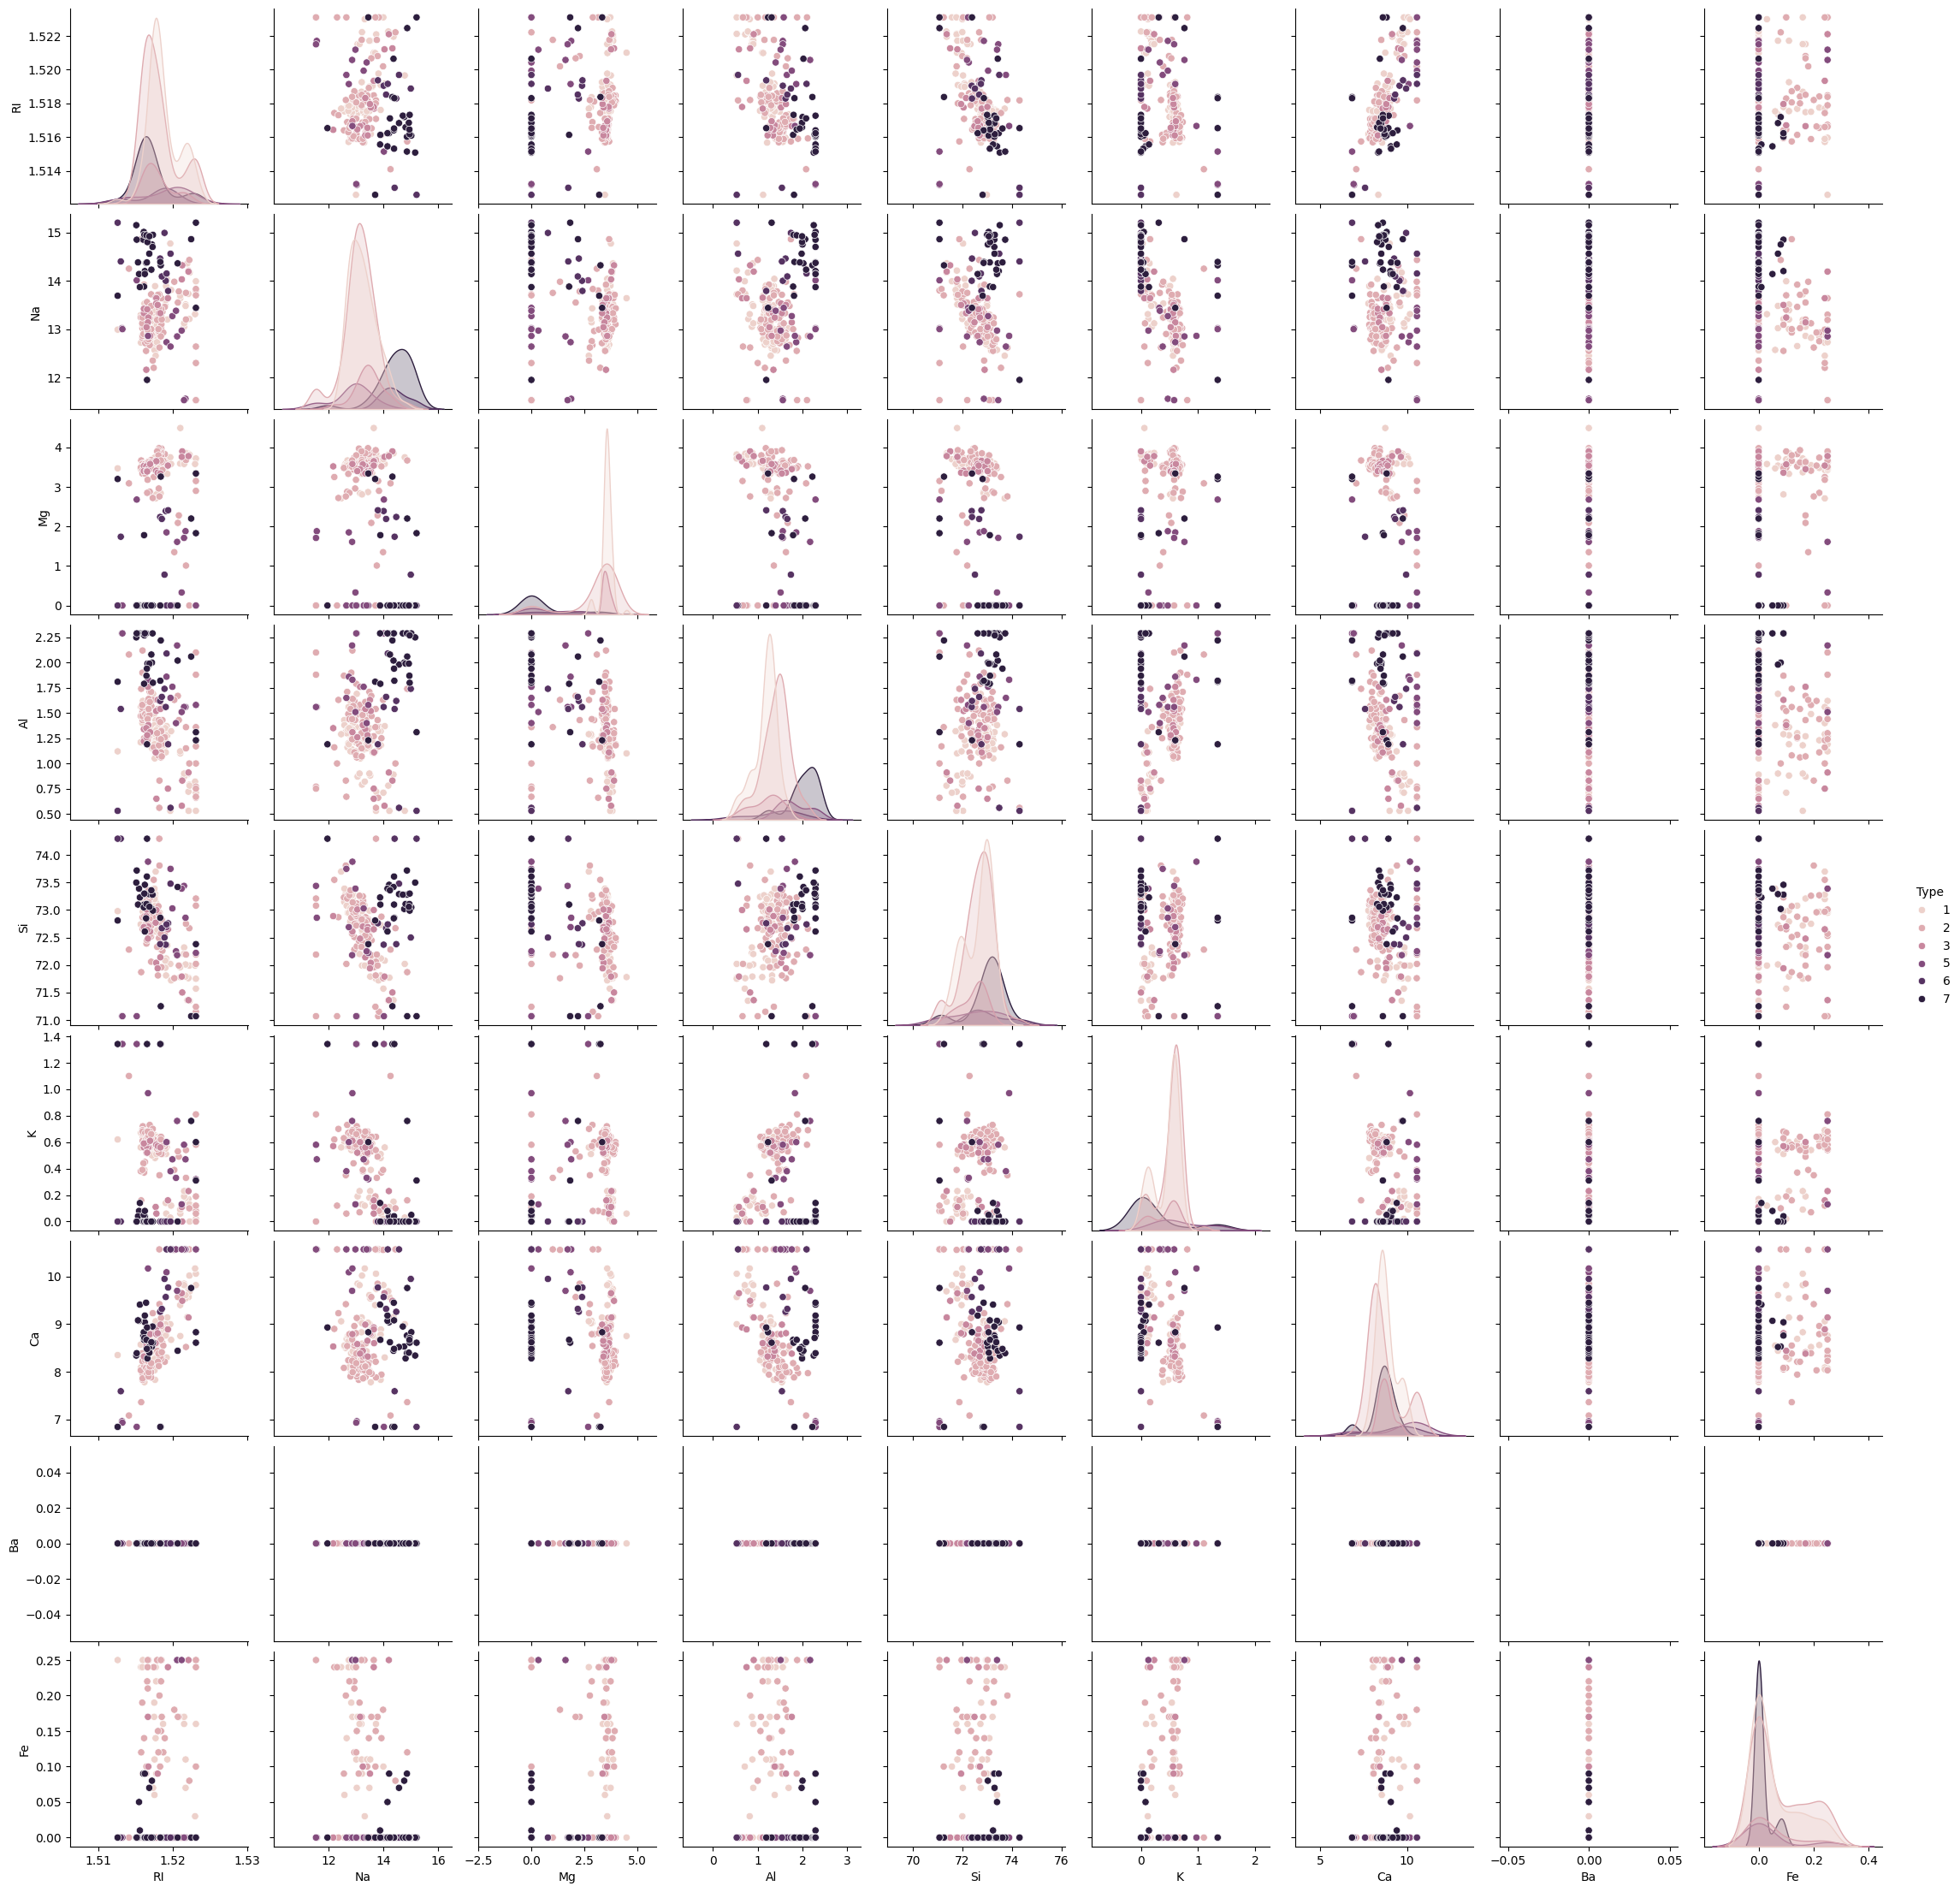

In [29]:
#histogram
df.hist(figsize=(12,10), bins=15)
plt.suptitle("Histogram of Glass Dataset Features")
plt.tight_layout()
plt.show()
#boxplot
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Box Plot of Glass Dataset Features")
plt.show()
#pairplot
sns.pairplot(df, hue='Type')
plt.show()

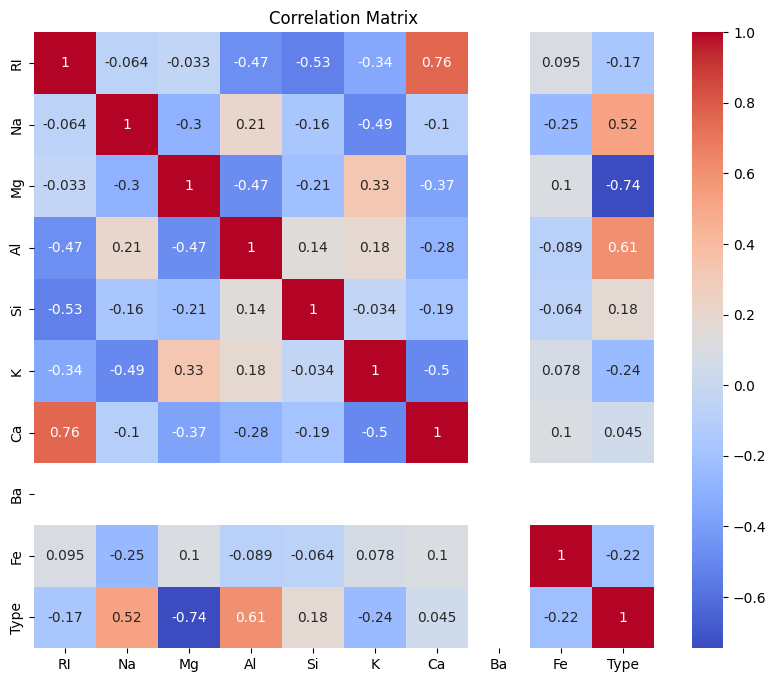

In [30]:
#corelation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Analyze any patterns or correlations observed in the data.   
**Answer:** Analysis of Patterns and Correlations
The histograms show the distribution of each numerical feature. Most features are continuous, while some exhibit skewed distributions.   
The box plots reveal the presence of outliers in several features. These outliers may represent rare glass samples and should be handled carefully.       
The pair plots illustrate the relationships between features and the different glass types. Some glass classes show partial separation, while others overlap, indicating that multiple features are needed for accurate classification.    
The correlation matrix indicates that some features are positively correlated, while others are negatively correlated. Highly correlated features may contain similar information and can influence the model's learning process.   
Features with stronger relationships to the target variable (Type) are likely to contribute more to the classification performance of the Random Forest model.   
Overall, the visualizations suggest that the dataset contains meaningful patterns that can help distinguish between different types of glass, making it suitable for classification using Random Forest.

**3: Data Preprocessing**

1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.

In [31]:
# Check missing values
df.isnull().sum()
# Remove rows with missing values
df = df.dropna()
# Fill missing numerical values with the mean
df.fillna(df.mean(numeric_only=True), inplace=True)
# Check again
df.isnull().sum()

,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


**Explanation:**
The dataset was first checked for missing values using df.isnull().sum(). Since machine learning algorithms cannot handle missing values directly, they must be addressed before model training. If only a few records contain missing values, removing those rows using dropna() is appropriate. If many values are missing, imputing numerical columns with their mean using fillna() helps preserve the dataset while minimizing information loss.  
For the Glass dataset: The original UCI Glass dataset typically does not contain missing values. If df.isnull().sum() returns 0 for all columns, you can simply mention that no preprocessing for missing values was required.

2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.

In [32]:
#checking categorical variables
df.select_dtypes(include='object').columns

Index([], dtype='object')

**Explanation:**
The Glass dataset contains only numerical input features, so no categorical variables required encoding. Therefore, One-Hot Encoding was not applied. If categorical variables were present, One-Hot Encoding would be used to convert them into numerical format suitable for machine learning algorithms

3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.

In [34]:
#Standardization (StandardScaler)
from sklearn.preprocessing import StandardScaler
X = df.drop('Type', axis=1)
y = df['Type']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [37]:
#Normalization (MinMaxScaler)
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
X_normalized = mms.fit_transform(X)

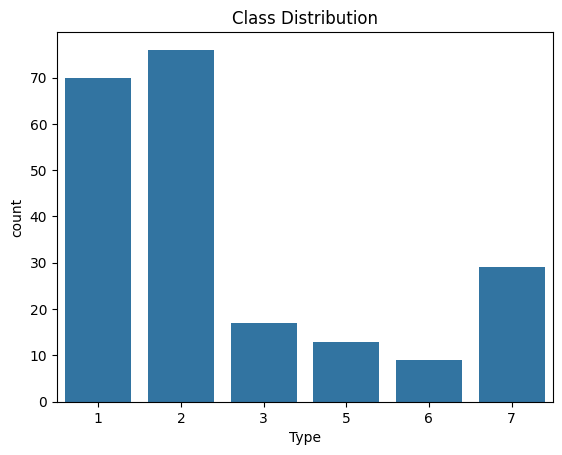

In [39]:
#Check Class Distribution (Imbalanced Data)
df['Type'].value_counts()
sns.countplot(x='Type', data=df)
plt.title("Class Distribution")
plt.show()

In [40]:
#Handle Imbalanced Data
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
print(y_resampled.value_counts())

Type
1    76
2    76
3    76
5    76
6    76
7    76
Name: count, dtype: int64


**Explanation:**   
Standardization scales features to have a mean of 0 and a standard deviation of 1.   
Normalization scales features to a range between 0 and 1.   
The class distribution was checked to determine whether the dataset was imbalanced.   
If class imbalance was present, SMOTE (Synthetic Minority Oversampling Technique) was applied to generate synthetic samples for the minority classes, resulting in a more balanced dataset for training the Random Forest model.

**4: Random Forest Model Implementation**
1. Divide the data into train and test split.

In [41]:
from sklearn.model_selection import train_test_split
# Features and Target
X = df.drop('Type', axis=1)
y = df['Type']
# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [42]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (171, 9)
Testing Features : (43, 9)
Training Labels  : (171,)
Testing Labels   : (43,)


2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.

In [43]:
#import model
from sklearn.ensemble import RandomForestClassifier
#create randomforest model
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

In [45]:
#train the model
rf_model.fit(X_train, y_train)
#prediction
y_pred = rf_model.predict(X_test)
#display prediction
print(y_pred)

[7 5 2 5 1 2 2 2 1 1 3 1 7 6 1 7 7 1 1 2 1 1 7 2 1 3 2 6 2 1 2 1 1 7 2 2 1
 1 2 1 1 2 7]


3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.

In [46]:
#train the randomforest model
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [47]:
#predict the test
y_pred = rf_model.predict(X_test)

In [48]:
#evaluate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [50]:
#evaluate the model
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1-Score :", f1_score(y_test, y_pred, average='weighted'))
#display clasification report
print(classification_report(y_test, y_pred))

Accuracy : 0.7674418604651163
Precision: 0.7797687948166744
Recall   : 0.7674418604651163
F1-Score : 0.7644559491521231
              precision    recall  f1-score   support

           1       0.76      0.93      0.84        14
           2       0.77      0.67      0.71        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.50      0.50      0.50         2
           7       0.71      0.83      0.77         6

    accuracy                           0.77        43
   macro avg       0.79      0.71      0.74        43
weighted avg       0.78      0.77      0.76        43



**5: Bagging and Boosting Methods**

Apply the Bagging and Boosting methods and compare the results.

In [51]:
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [52]:
#Bagging classifier
bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=100,random_state=42)
bagging_model.fit(X_train, y_train)
y_pred_bag = bagging_model.predict(X_test)

In [55]:
#Evaluate Boost models
print("Bagging Results")
print("Accuracy :", accuracy_score(y_test, y_pred_bag))
print("Precision:", precision_score(y_test, y_pred_bag, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_bag, average='weighted'))
print("F1-Score :", f1_score(y_test, y_pred_bag, average='weighted'))

Bagging Results
Accuracy : 0.7674418604651163
Precision: 0.7801771871539315
Recall   : 0.7674418604651163
F1-Score : 0.766158781074579


In [56]:
#Boosting classifier(Ada boost)
boosting_model = AdaBoostClassifier(n_estimators=100,random_state=42)
boosting_model.fit(X_train, y_train)
y_pred_boost = boosting_model.predict(X_test)

In [57]:
print("Boosting Results")
print("Accuracy :", accuracy_score(y_test, y_pred_boost))
print("Precision:", precision_score(y_test, y_pred_boost, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_boost, average='weighted'))
print("F1-Score :", f1_score(y_test, y_pred_boost, average='weighted'))

Boosting Results
Accuracy : 0.4186046511627907
Precision: 0.37749169435215946
Recall   : 0.4186046511627907
F1-Score : 0.39515026539886206


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [58]:
#Compare the Results
comparison = pd.DataFrame({
"Model": ["Bagging", "Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_bag),
        accuracy_score(y_test, y_pred_boost)
    ],
    "Precision": [
        precision_score(y_test, y_pred_bag, average='weighted'),
        precision_score(y_test, y_pred_boost, average='weighted')
    ],
    "Recall": [
        recall_score(y_test, y_pred_bag, average='weighted'),
        recall_score(y_test, y_pred_boost, average='weighted')
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_bag, average='weighted'),
        f1_score(y_test, y_pred_boost, average='weighted')
    ]
})
comparison

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-Score
0,Bagging,0.767442,0.780177,0.767442,0.766159
1,Boosting,0.418605,0.377492,0.418605,0.395150


**Additional Notes:**
1. Explain Bagging and Boosting methods. How is it different from each other.

**Bagging (Bootstrap Aggregating)**

Bagging is an ensemble learning technique that combines predictions from multiple models trained on different random subsets of the training data.   
It helps reduce variance and improves the stability and accuracy of the model.   
Each model is trained independently.
The final prediction is made using majority voting (classification) or averaging (regression).   
Example: Random Forest is a popular Bagging algorithm.   
**Boosting**    
Boosting is an ensemble learning technique that builds models sequentially.   
Each new model focuses on correcting the errors made by the previous model.   
It helps reduce bias and improves predictive performance.   
The final prediction is obtained by combining the weighted predictions of all models.   
Examples: AdaBoost, Gradient Boosting, XGBoost.          
**Difference Between Bagging and Boosting**    
**Bagging**   
Models are trained independently.
Uses random bootstrap samples of the data.   Mainly reduces variance.    
Final prediction is based on majority voting or averaging.  
Less sensitive to noise and outliers.   Training can be done in parallel.    Example: Random Forest.     
**Boosting**               
Models are trained sequentially.   
Each model learns from the errors of the previous model.   
Mainly reduces bias.     
Final prediction is based on weighted voting or weighted combination.     
More sensitive to noise and outliers.     Training cannot be parallelized because each model depends on the previous one.       
Examples: AdaBoost, Gradient Boosting, XGBoost

2. Explain how to handle imbalance in the data.    
**Answer:**    
**Handling Imbalanced Data**
Imbalanced data occurs when one class has significantly more samples than the other classes.   This can cause the model to become biased toward the majority class and reduce its ability to correctly predict the minority class.    
**Common Techniques to Handle Imbalanced Data**   
**Oversampling**:
Increases the number of samples in the minority class.  
A popular technique is SMOTE (**Synthetic** Minority Over-sampling Technique), which creates synthetic examples instead of simply duplicating existing ones.  
**Undersampling:**
Reduces the number of samples in the majority class.  
This balances the dataset but may result in the loss of useful information.  
**Class Weighting:**
Assigns higher weights to minority class samples during model training.    
Many machine learning algorithms, such as Decision Trees and Random Forests, support the class_weight='balanced' option.     
**Ensemble Methods:**
Methods such as Balanced Random Forest and EasyEnsemble are specifically designed to improve performance on imbalanced datasets.  
**Appropriate Evaluation Metrics**:
Instead of relying only on accuracy, use metrics such as:  
Precision  
Recall  
F1-score  
ROC-AUC  
These metrics provide a better assessment of performance on imbalanced datasets.